#Model Development

## Step 1: Import Required Libraries

Machine learning projects require different libraries for data manipulation, visualization, preprocessing, model building, evaluation, and model saving.

The following libraries are imported to perform these tasks efficiently.



In [11]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame.

This allows us to inspect the data, understand its structure, and perform preprocessing before model development.

In [2]:
df = pd.read_csv("/content/placedata_v2_0_synthetic.csv")
df.head(10)

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
5,6,7.0,0,2,2,71,4.2,Yes,No,55,66,NotPlaced
6,7,7.7,1,1,1,76,4.0,No,No,62,65,NotPlaced
7,8,7.7,2,1,0,85,3.5,Yes,Yes,59,72,NotPlaced
8,9,6.5,1,1,0,84,3.9,No,Yes,75,71,NotPlaced
9,10,7.8,1,3,2,79,4.4,Yes,Yes,85,86,Placed


In [5]:
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


## Step 3: Encode Categorical Features

Machine learning algorithms cannot process text values directly.

Therefore, categorical variables such as Placement Status and Extracurricular Activities are converted into numerical labels using Label Encoding.

This transformation makes the dataset suitable for machine learning algorithms.

In [30]:
Le = LabelEncoder()
df['ExtracurricularActivities'] = Le.fit_transform(df['ExtracurricularActivities'])
df['PlacementStatus'] = Le.fit_transform(df['PlacementStatus'])
df['PlacementTraining'] = Le.fit_transform(df['PlacementTraining'])

df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,0,0,61,79,0
1,2,8.9,0,3,2,90,4.0,1,1,78,82,0
2,3,7.3,1,2,2,82,4.8,1,0,79,80,0
3,4,7.5,1,1,2,85,4.4,1,1,81,80,0
4,5,8.3,1,2,2,86,4.5,1,1,74,88,0


## Step 4: Separate Features and Target Variable

The dataset is divided into:

- Features (X): Independent variables used for prediction.
- Target (y): Placement Status.

The model learns the relationship between the input features and the target variable.

In [20]:
X = df.drop(['PlacementStatus','StudentID'],axis=1)
y = df['PlacementStatus']


## Step 5: Split the Dataset

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The training data is used to train the model, while the testing data is used to evaluate how well the model performs on unseen data.

This helps estimate the model's generalization ability and reduces the risk of overfitting.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 6: Train Machine Learning Models

Several classification algorithms are trained to identify the most suitable model for predicting student placement.

The models used include:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine
- AdaBoost
- Gradient Boosting

Training multiple models allows us to compare their performance and choose the most effective algorithm.

In [38]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression — Test Set Performance\n")
print(classification_report(y_test, y_pred))



Logistic Regression — Test Set Performance

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000



In [39]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]
print("K-Nearest Neighbors — Test Set Performance\n")
print(classification_report(y_test, y_pred))

K-Nearest Neighbors — Test Set Performance

              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1172
           1       0.71      0.70      0.71       828

    accuracy                           0.76      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.76      0.76      0.76      2000



In [40]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]
print("Decision Tree — Test Set Performance\n")
print(classification_report(y_test, y_pred))

Decision Tree — Test Set Performance

              precision    recall  f1-score   support

           0       0.77      0.76      0.76      1172
           1       0.67      0.68      0.67       828

    accuracy                           0.73      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000



In [41]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
print("Random Forest — Test Set Performance\n")
print(classification_report(y_test, y_pred))

Random Forest — Test Set Performance

              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1172
           1       0.75      0.71      0.73       828

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



In [42]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]
print("SVM (RBF) — Test Set Performance\n")
print(classification_report(y_test, y_pred))

SVM (RBF) — Test Set Performance

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1172
           1       0.73      0.74      0.73       828

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



In [43]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
y_prob = ada.predict_proba(X_test)[:, 1]
print("AdaBoost — Test Set Performance\n")
print(classification_report(y_test, y_pred))

AdaBoost — Test Set Performance

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1172
           1       0.75      0.75      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



In [44]:
gd = GradientBoostingClassifier()
gd.fit(X_train, y_train)
y_pred = gd.predict(X_test)
y_prob = gd.predict_proba(X_test)[:, 1]
print("Gradient Boosting — Test Set Performance\n")
print(classification_report(y_test, y_pred))

Gradient Boosting — Test Set Performance

              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1172
           1       0.75      0.74      0.74       828

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



## Step 7: Compare Model Performance

Each model is evaluated using multiple performance metrics instead of relying only on accuracy.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Comparing these metrics helps identify the model that provides the best balance between correctly identifying placed and non-placed students.

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs) if probs is not None else np.nan,
    })
    fitted_models[name] = model

results_df = pd.DataFrame(baseline_results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7905,0.7178,0.8140,0.7629,0.8769
1,AdaBoost,0.7920,0.7500,0.7464,0.7482,0.8742
2,Gradient Boosting,0.7910,0.7531,0.7367,0.7448,0.8741
3,SVM (RBF),0.7745,0.7051,0.7826,0.7418,0.8569
4,Random Forest,0.7815,0.7472,0.7138,0.7301,0.8680
5,K-Nearest Neighbors,0.7705,0.7264,0.7150,0.7206,0.8257
6,Decision Tree,0.7225,0.6612,0.6763,0.6687,0.7151


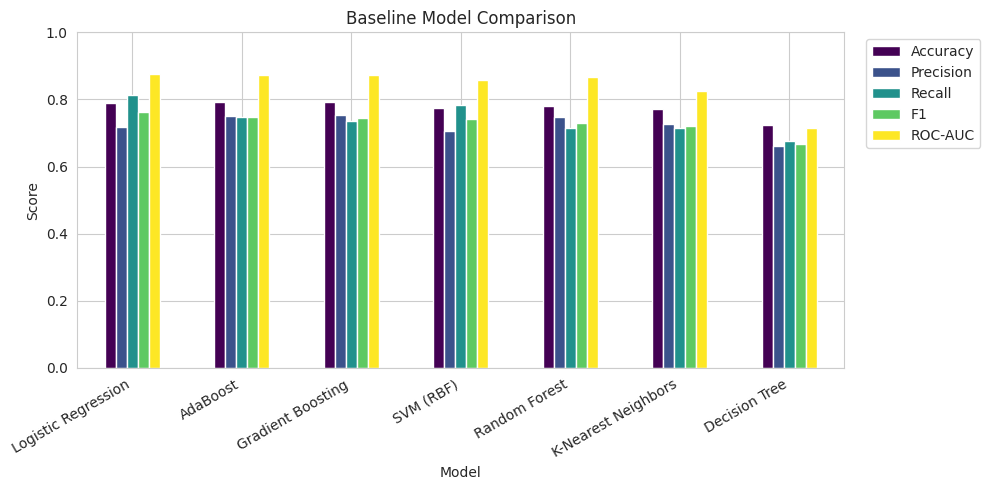

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='viridis')
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Step 8: Select the Best Performing Model

The model with the highest overall evaluation metrics is selected as the baseline model.

This model will be further improved using hyperparameter tuning to achieve better predictive performance.

In [23]:
best_baseline_name = results_df.iloc[0]['Model']
print(f"Best baseline model: {best_baseline_name}")

Best baseline model: Logistic Regression


## Step 9: Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV.

Instead of using default parameter values, Grid Search tests multiple parameter combinations and selects the one that gives the best cross-validation performance.

This improves the model's accuracy and robustness.

In [24]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 8, 12, 16],
        'min_samples_split': [2, 5, 10],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4],
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
    },
    'Decision Tree': {
        'max_depth': [None, 4, 8, 12],
        'min_samples_split': [2, 5, 10],
    },
}

base_estimator = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
}[best_baseline_name]

grid = GridSearchCV(base_estimator, param_grids[best_baseline_name],
                     scoring='f1', cv=5, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Best params: {'C': 1, 'solver': 'lbfgs'}
Best CV F1: 0.7679


#Final Evaluation on Test set
## Step 10: Evaluate the Optimized Model

The optimized model is evaluated on the testing dataset.

The following evaluation techniques are used:

- Classification Report
- Confusion Matrix
- ROC Curve
- ROC-AUC Score

These metrics provide a comprehensive assessment of the model's predictive performance.

In [26]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Tuned {best_baseline_name} — Test Set Performance\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Tuned Logistic Regression — Test Set Performance

              precision    recall  f1-score   support

           0       0.85      0.77      0.81      1172
           1       0.72      0.81      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000

ROC-AUC: 0.8769


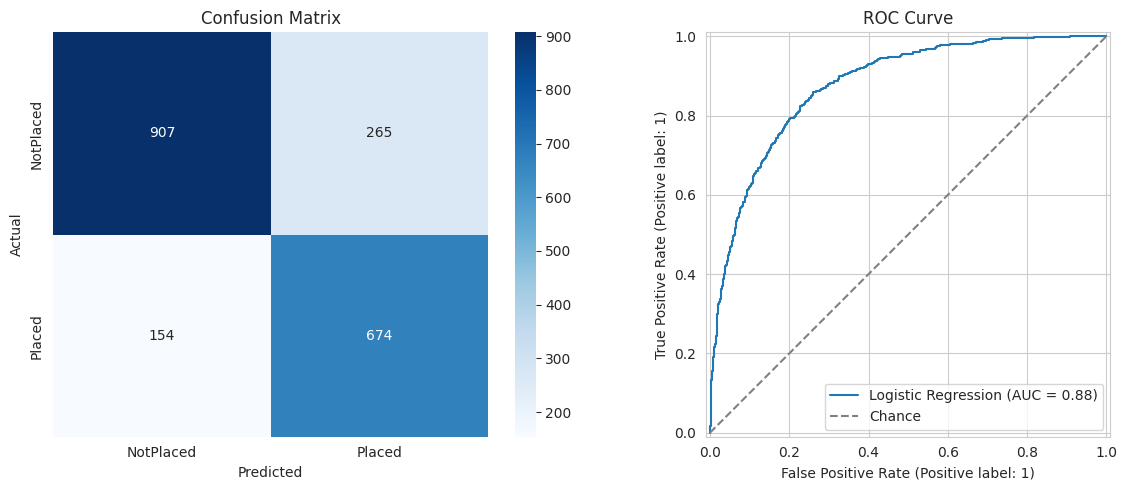

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_labels = ['NotPlaced', 'Placed']  # index 0 = NotPlaced, index 1 = Placed

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=best_baseline_name)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

#Cross - Validation Stability Check
## Step 11: Cross Validation

Five-fold Cross Validation is performed to measure the model's consistency across different subsets of the training data.

Cross validation provides a more reliable estimate of the model's real-world performance compared to a single train-test split.

In [32]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
print(f"5-fold CV F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-fold CV F1 scores: [0.7616 0.7707 0.7509 0.7846 0.7718]
Mean: 0.7679  |  Std: 0.0113


#Feature Importance
## Step 12: Feature Importance Analysis

Feature importance identifies the variables that contribute most to placement prediction.

Understanding influential features helps interpret the model and provides insights into the factors affecting campus placements.

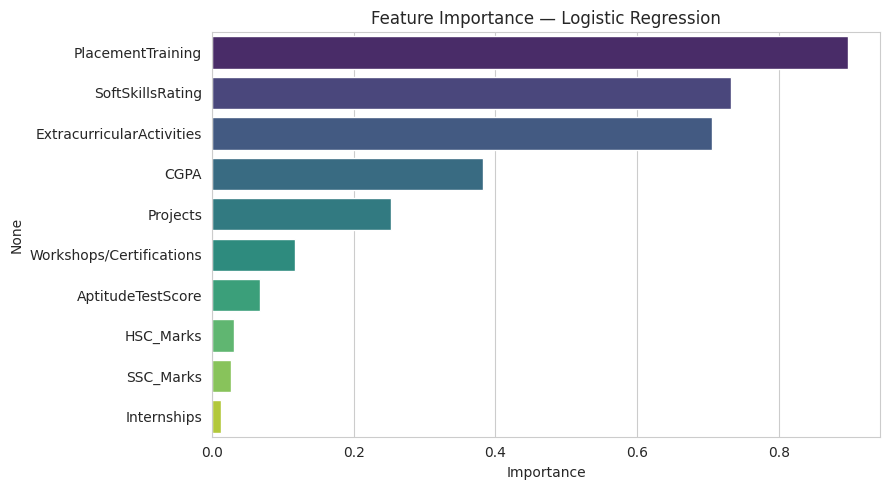

PlacementTraining            0.8978
SoftSkillsRating             0.7318
ExtracurricularActivities    0.7057
CGPA                         0.3818
Projects                     0.2533
Workshops/Certifications     0.1173
AptitudeTestScore            0.0685
HSC_Marks                    0.0319
SSC_Marks                    0.0265
Internships                  0.0128
dtype: float64


In [33]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns).sort_values(ascending=False)
else:
    importances = None

if importances is not None:
    plt.figure(figsize=(9, 5))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
                palette='viridis', legend=False)
    plt.title(f'Feature Importance — {best_baseline_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(importances.round(4))
else:
    print(f"{best_baseline_name} does not expose a direct feature importance / coefficient attribute.")

#Saving Best Model:
## Step 13: Save the Trained Model

The final optimized model is saved using Joblib.

Saving the model allows it to be reused later without retraining, making deployment in web applications or APIs much easier.

In [35]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/placement_model.pkl')
print(f"Saved tuned {best_baseline_name} to models/placement_model.pkl")

Saved tuned Logistic Regression to models/placement_model.pkl


# Final Results and Conclusion

## Best Performing Model

Seven machine learning classification algorithms were trained and evaluated for Engineering Campus Placement Prediction. The performance of each model was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

### Model Performance Summary

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|--------|---------:|----------:|-------:|---------:|---------:|
| Logistic Regression | 79.05% | 71.78% | **81.40%** | **76.29%** | **87.69%** |
| AdaBoost | **79.20%** | 75.00% | 74.64% | 74.82% | 87.42% |
| Gradient Boosting | 79.10% | **75.31%** | 73.67% | 74.48% | 87.41% |
| SVM (RBF) | 77.45% | 70.51% | 78.26% | 74.18% | 85.69% |
| Random Forest | 78.15% | 74.72% | 71.38% | 73.01% | 86.80% |
| K-Nearest Neighbors | 77.05% | 72.64% | 71.50% | 72.06% | 82.57% |
| Decision Tree | 72.25% | 66.12% | 67.63% | 66.87% | 71.51% |

## Selected Model

Although **AdaBoost** achieved the highest accuracy (**79.20%**), **Logistic Regression** was selected as the preferred model because it achieved:

- Highest Recall (**81.40%**)
- Highest F1-Score (**76.29%**)
- Highest ROC-AUC Score (**87.69%**)

These metrics indicate that Logistic Regression provides a better balance between identifying placed students correctly and maintaining overall classification performance. Therefore, it offers stronger generalization for this placement prediction task.

## Conclusion

This project successfully developed a machine learning model for predicting engineering campus placements by following a complete machine learning workflow:

- Data Loading and Exploration
- Data Preprocessing and Feature Encoding
- Train-Test Split
- Model Training
- Performance Evaluation
- Model Comparison
- Hyperparameter Tuning
- Cross Validation
- Model Saving

Among the evaluated algorithms, **Logistic Regression** demonstrated the best overall performance, while **AdaBoost** achieved the highest accuracy. Considering multiple evaluation metrics rather than accuracy alone, Logistic Regression was selected as the final model for this project.

The trained model can be integrated into a web application where students can enter their academic and skill-related information to receive a prediction of their campus placement likelihood.